In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="TEoE9TIzrU3jvIMDdYys")
project = rf.workspace("blue-halo").project("vegetation-segmentation")
version = project.version(4)
dataset = version.download("yolov8")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 129.1 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to vegetation-segmentation-4 in yolov8:: 100%|██████████| 2148/2148 [00:00<00:00, 2407.72it/s]


data preprocessing

In [ ]:
!pip install ultralytics
!pip install opencv-python
!pip install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.9 MB/s eta 0:00:00


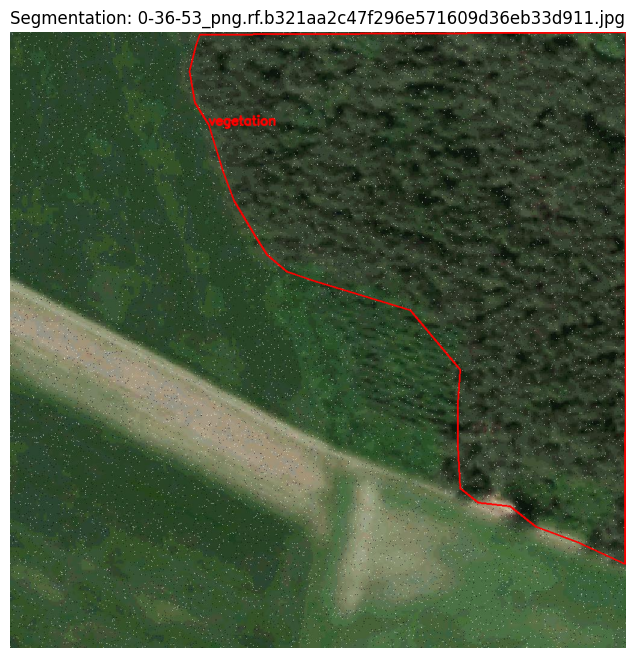

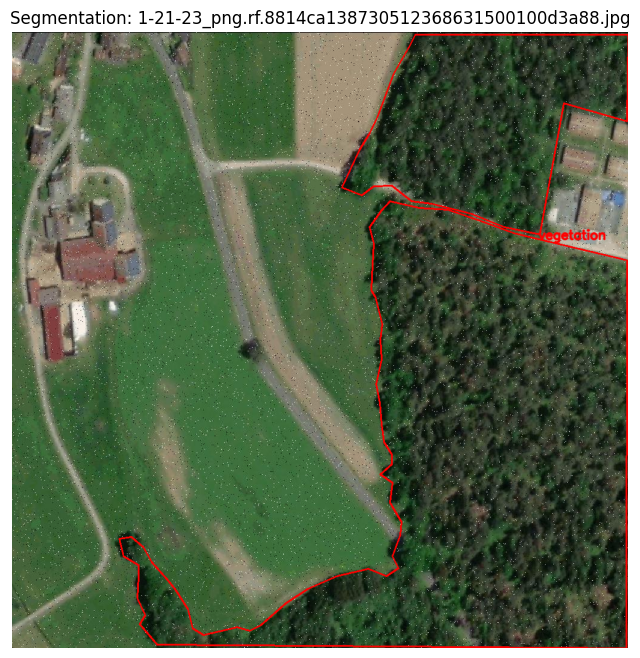

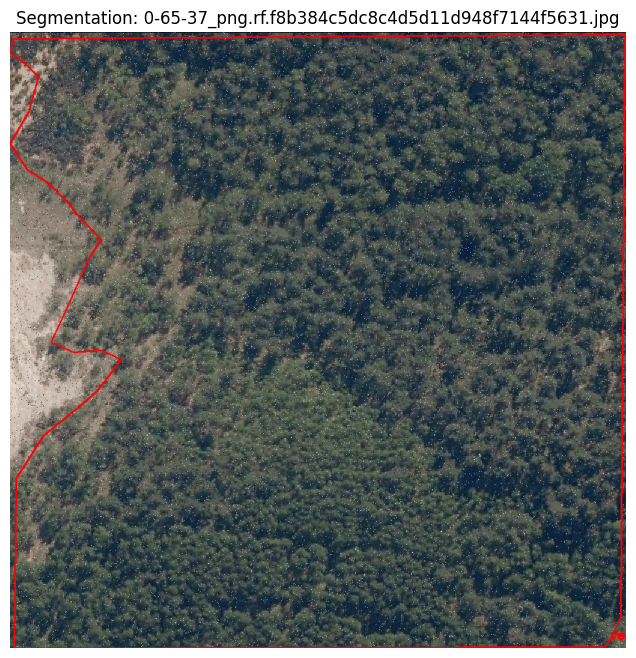

Sample segmentation images displayed.


In [ ]:
#show image with segementation
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# Paths
# ------------------------
dataset_path = 'vegetation-segmentation-4'
image_dir = os.path.join(dataset_path, 'train', 'images')
label_dir = os.path.join(dataset_path, 'train', 'labels')

# Get list of image files
image_files = [f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]

# Select first 3 sample images
sample_image_files = image_files[:3]

# Dataset class names (from data.yaml)
class_names = ['vegetation']


# --------------------------------------------------------
# Function: Parse YOLO Polygon Segmentation Labels
# --------------------------------------------------------
def parse_yolo_segmentation(label_path, img_width, img_height):
    polygons = []

    if not os.path.exists(label_path):
        return polygons

    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            class_id = int(parts[0])
            coords = list(map(float, parts[1:]))

            # Convert normalized coords → pixel coords
            polygon = []
            for i in range(0, len(coords), 2):
                x = int(coords[i] * img_width)
                y = int(coords[i + 1] * img_height)
                polygon.append((x, y))

            polygons.append({
                'class_id': class_id,
                'polygon': polygon
            })

    return polygons


# --------------------------------------------------------
# Visualization Loop
# --------------------------------------------------------
for img_file in sample_image_files:

    # Load image
    img_path = os.path.join(image_dir, img_file)
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img_rgb.shape[:2]

    # Load corresponding label
    label_name = os.path.splitext(img_file)[0] + '.txt'
    label_path = os.path.join(label_dir, label_name)

    annotations = parse_yolo_segmentation(label_path, w, h)

    # Draw polygons
    for ann in annotations:
        polygon = ann['polygon']
        class_id = ann['class_id']
        class_name = class_names[class_id]

        pts = np.array(polygon, np.int32)

        # Draw polygon outline
        cv2.polylines(img_rgb, [pts], isClosed=True, color=(255, 0, 0), thickness=2)

        # Draw class label
        cv2.putText(img_rgb, class_name, pts[0], cv2.FONT_HERSHEY_SIMPLEX,
                    0.7, (255, 0, 0), 2, cv2.LINE_AA)

    # Display (Matplotlib)
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title(f"Segmentation: {img_file}")
    plt.axis('off')
    plt.show()

print("Sample segmentation images displayed.")


In [ ]:
#Show all files
print(f"\nContents of '{dataset_path}/train/images/':")
!ls -F {dataset_path}/train/images/



Contents of 'vegetation-segmentation-4/train/images/':
0-0-0_png.rf.754c9fc383df9c2fbd6fe7d2432caefa.jpg
0-0-0_png.rf.aa38230822d36971260fd79ea402ea43.jpg
0-0-0_png.rf.fa6e717479576f1d9c46542752eb7567.jpg
0-0-10_png.rf.2853f4c5f8dc0df2b586fa30593aa136.jpg
0-0-10_png.rf.adef944fae446c1bceaeca8b9cd8afa4.jpg
0-0-10_png.rf.f72b99c6cddf0757845e83c80d77cb61.jpg
0-0-30_png.rf.30e722142e91e226b52e7b4abe26ddcb.jpg
0-0-30_png.rf.e5a7d8e0ec57aa86bdb9ebe9a799064b.jpg
0-0-30_png.rf.f09315fab8cd8391576c361bd383faa8.jpg
0-0-34_png.rf.03b3dc6cc76b8b2e7aafb67898f49e18.jpg
0-0-34_png.rf.a637531d29f5e8c7b615afed418d07f9.jpg
0-0-34_png.rf.ff26afc280ce8727749cfc6e4936a8fb.jpg
0-10-11_png.rf.56410a4d42e12de9e6ffe5744e4be99d.jpg
0-10-11_png.rf.f38f326c21a50d52eed0ed84c5011fc8.jpg
0-10-11_png.rf.fe10ec22b65445ea836d15baee992145.jpg
0-10-15_png.rf.0434ee569db28af0cc6d9a89d64f518f.jpg
0-10-15_png.rf.30fb09b0c72a030667012e30435f6f34.jpg
0-10-15_png.rf.6a890a07780c8ff1fecf1c375fcf7619.jpg
0-10-47_png.rf.6e64726b

In [ ]:
#Show first 5 files
print(f"\nContents of '{dataset_path}/train/images/':")
!ls -F {dataset_path}/train/images/ | head -n 5



Contents of 'vegetation-segmentation-4/train/images/':
0-0-0_png.rf.754c9fc383df9c2fbd6fe7d2432caefa.jpg
0-0-0_png.rf.aa38230822d36971260fd79ea402ea43.jpg
0-0-0_png.rf.fa6e717479576f1d9c46542752eb7567.jpg
0-0-10_png.rf.2853f4c5f8dc0df2b586fa30593aa136.jpg
0-0-10_png.rf.adef944fae446c1bceaeca8b9cd8afa4.jpg


In [ ]:
#Show first 10 files
print(f"\nContents of '{dataset_path}/train/images/':")
!ls -F {dataset_path}/train/images/ | head -n 10



Contents of 'vegetation-segmentation-4/train/images/':
0-0-0_png.rf.754c9fc383df9c2fbd6fe7d2432caefa.jpg
0-0-0_png.rf.aa38230822d36971260fd79ea402ea43.jpg
0-0-0_png.rf.fa6e717479576f1d9c46542752eb7567.jpg
0-0-10_png.rf.2853f4c5f8dc0df2b586fa30593aa136.jpg
0-0-10_png.rf.adef944fae446c1bceaeca8b9cd8afa4.jpg
0-0-10_png.rf.f72b99c6cddf0757845e83c80d77cb61.jpg
0-0-30_png.rf.30e722142e91e226b52e7b4abe26ddcb.jpg
0-0-30_png.rf.e5a7d8e0ec57aa86bdb9ebe9a799064b.jpg
0-0-30_png.rf.f09315fab8cd8391576c361bd383faa8.jpg
0-0-34_png.rf.03b3dc6cc76b8b2e7aafb67898f49e18.jpg


In [ ]:
#image scalling
import os
import cv2

# --------------------------
# Paths
# --------------------------
input_dir = "vegetation-segmentation-4/train/images"
output_dir = "vegetation-segmentation-4/train/images_resized"

# Create output folder if not exists
os.makedirs(output_dir, exist_ok=True)

# Desired image size (change if needed)
TARGET_SIZE = (640, 640)

# --------------------------
# Resize Images
# --------------------------
image_files = [
    f for f in os.listdir(input_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("🔄 Scaling Images...")

for img_name in image_files:
    img_path = os.path.join(input_dir, img_name)

    # Load image
    img = cv2.imread(img_path)

    # Skip corrupted images
    if img is None:
        print(f" Could not read image: {img_name}")
        continue

    # Resize
    resized = cv2.resize(img, TARGET_SIZE)

    # Save output image
    save_path = os.path.join(output_dir, img_name)
    cv2.imwrite(save_path, resized)

print("\n Image Scaling Completed!")
print(f" All resized images saved to: {output_dir}")


🔄 Scaling Images...

 Image Scaling Completed!
 All resized images saved to: vegetation-segmentation-4/train/images_resized


In [ ]:
import os
import cv2

# Paths
image_dir = 'vegetation-segmentation-4/train/images'
label_dir = 'vegetation-segmentation-4/train/labels'

# Lists to store issues
corrupted_images = []
missing_labels = []
empty_labels = []
invalid_format = []

# Get all image files
image_files = [f for f in os.listdir(image_dir)
               if f.lower().endswith(('jpg','jpeg','png'))]

print("Starting dataset cleaning...\n")

for img_name in image_files:
    img_path = os.path.join(image_dir, img_name)
    label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + ".txt")

    # ---- 1. Check if image is corrupted ----
    img = cv2.imread(img_path)
    if img is None:
        corrupted_images.append(img_name)
        continue

    # ---- 2. Check if label exists ----
    if not os.path.exists(label_path):
        missing_labels.append(img_name)
        continue

    # ---- 3. Check if label file is empty ----
    with open(label_path, "r") as f:
        lines = f.readlines()

    if len(lines) == 0:
        empty_labels.append(img_name)
        continue

    # ---- 4. Validate YOLO label format ----
    # Format: class x_center y_center width height
    for line in lines:
        parts = line.strip().split()

        # Minimum 5 numbers required
        if len(parts) != 5:
            invalid_format.append((img_name, "Invalid YOLO format"))
            break

        # Check if all values are numeric
        try:
            float_values = [float(x) for x in parts]
        except:
            invalid_format.append((img_name, "Non-numeric values"))
            break

print("\nDATA CLEANING REPORT")
print("--------------------------------------------------")
print("Corrupted Images:", corrupted_images)
print("Missing Labels:", missing_labels)
print("Empty Label Files:", empty_labels)
print("Invalid Label Format:", invalid_format)
print("\nCleaning Completed Successfully!")

Starting dataset cleaning...


DATA CLEANING REPORT
--------------------------------------------------
Corrupted Images: []
Missing Labels: []
Empty Label Files: ['0-28-27_png.rf.d67cd5a11a790dde3e922e3b4e7a8461.jpg', '1-32-12_png.rf.3a20ce024afa2bec45fa181efecc2738.jpg', '0-67-27_png.rf.8e3d83501a5ddda2726c1cd2b05393ec.jpg', '0-65-59_png.rf.8d39e7e92d495228cabad40ee2883c61.jpg', '1-32-12_png.rf.8b14b3fc62c1ac27f6e27045d4fe6592.jpg', '0-13-58_png.rf.265f41cd185db799e8694047989110a3.jpg', '0-10-47_png.rf.6e64726bce9c25f762627a83871e78c7.jpg', '0-16-15_png.rf.81f41aebbc2da57cb12d8d47d7289347.jpg', '0-4-44_png.rf.d7ea9deddd6d65c0b5da205fac010231.jpg', '0-28-27_png.rf.fc188c674b53659e075f1302f681e844.jpg', '0-26-24_png.rf.5c4d78e75ef33914ae0453a53628d3b0.jpg', '0-36-52_png.rf.e0d0877d0f72b80da5c5600b8f9aa309.jpg', '2-20-5_png.rf.1b7acba530a0a9186cfcc3fb1130a3c3.jpg', '0-4-7_png.rf.6dd45a83ab8bf6adf15abd469d4d44e7.jpg', '0-9-33_png.rf.0f97f03a092e7468ee8d26772c9ca8c9.jpg', '0-9-45_png.rf.a5

In [ ]:
# === Dataset Inspection Script (YOLO images + polygon labels) ===

import os
from pathlib import Path
from PIL import Image

DATA_DIR = Path('/content/vegetation-segmentation-4')   # change path if needed

def count_files(split):
    img_dir = DATA_DIR / split / 'images'
    lbl_dir = DATA_DIR / split / 'labels'

    imgs = sorted([p for p in img_dir.glob('*') if p.suffix.lower() in ['.jpg', '.jpeg', '.png']])
    lbls = sorted([p for p in lbl_dir.glob('*.txt')])

    return imgs, lbls

def check_mismatches(imgs, lbls):
    img_stems = {p.stem for p in imgs}
    lbl_stems = {p.stem for p in lbls}

    missing_labels = img_stems - lbl_stems
    missing_images = lbl_stems - img_stems

    return missing_labels, missing_images


print("===== DATASET SUMMARY =====\n")

total_images = 0
total_labels = 0

for split in ['train', 'valid', 'test']:
    imgs, lbls = count_files(split)

    print(f"{split.upper():5s} → images = {len(imgs):3d}, labels = {len(lbls):3d}")

    missing_lbl, missing_img = check_mismatches(imgs, lbls)

    if missing_lbl:
        print(f" Missing label files for: {len(missing_lbl)} images")
        # print(missing_lbl)

    if missing_img:
        print(f" Labels without images: {len(missing_img)}")
        # print(missing_img)

    total_images += len(imgs)
    total_labels += len(lbls)

print("\n==============================")
print(f"TOTAL IMAGES = {total_images}")
print(f"TOTAL LABELS = {total_labels}")
print("==============================\n")


# === Check data.yaml ===
yaml_path = DATA_DIR / 'data.yaml'

if yaml_path.exists():
    print("------ data.yaml ------")
    print(yaml_path.read_text())
else:
    print("No data.yaml found at:", yaml_path)


===== DATASET SUMMARY =====

TRAIN → images =   0, labels =   0
VALID → images =   0, labels =   0
TEST  → images =   0, labels =   0

TOTAL IMAGES = 0
TOTAL LABELS = 0

No data.yaml found at: /content/vegetation-segmentation-4/data.yaml


In [ ]:
#data agumentation
import os
import cv2
from pathlib import Path
import albumentations as A

# -------------------------
# CONFIG
# -------------------------
IMAGE_DIR = Path("/content/dataset/train/images")
LABEL_DIR = Path("/content/dataset/train/labels")
OUTPUT_IMG = Path("/content/augmented/images")
OUTPUT_LBL = Path("/content/augmented/labels")

OUTPUT_IMG.mkdir(parents=True, exist_ok=True)
OUTPUT_LBL.mkdir(parents=True, exist_ok=True)

# -------------------------
# AUGMENTATION PIPELINE
# -------------------------
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(p=0.5),
    A.ColorJitter(p=0.4),
    A.Rotate(limit=20, border_mode=cv2.BORDER_CONSTANT, p=0.4),
    A.GaussianBlur(p=0.2),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))


# -------------------------
# FUNCTION TO LOAD YOLO LABELS
# -------------------------
def load_yolo_labels(label_path):
    bboxes = []
    class_labels = []

    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue  # skip broken lines

            cls, x, y, w, h = parts
            class_labels.append(int(cls))
            bboxes.append([float(x), float(y), float(w), float(h)])

    return bboxes, class_labels


# -------------------------
# PROCESS ALL IMAGES
# -------------------------
for img_path in IMAGE_DIR.glob("*"):
    if img_path.suffix.lower() not in [".jpg", ".png", ".jpeg"]:
        continue

    label_path = LABEL_DIR / (img_path.stem + ".txt")
    if not label_path.exists():
        continue  # skip images without labels

    # Load image
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Load labels
    bboxes, class_labels = load_yolo_labels(label_path)

    # Apply augmentation
    augmented = transform(image=img, bboxes=bboxes, class_labels=class_labels)

    aug_img = augmented["image"]
    aug_bboxes = augmented["bboxes"]
    aug_labels = augmented["class_labels"]

    # Save augmented IMAGE
    out_img_path = OUTPUT_IMG / f"{img_path.stem}_aug.jpg"
    cv2.imwrite(
        str(out_img_path),
        cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR)
    )

    # Save augmented LABEL
    out_lbl_path = OUTPUT_LBL / f"{img_path.stem}_aug.txt"
    with open(out_lbl_path, "w") as f:
        for cls, (x, y, w, h) in zip(aug_labels, aug_bboxes):
            f.write(f"{cls} {x} {y} {w} {h}\n")

print("✔ Data augmentation completed successfully!")


✔ Data augmentation completed successfully!
